# CCPP Energy Output Prediction
## Machine Learning Regression Project
**Author:** William Pena
**Dataset:** Combined Cycle Power Plant (9,568 rows)
**Models:** Linear Regression vs Random Forest
**Best R²:** 0.9617 (Random Forest)

In [ ]:
import pandas as pd


In [ ]:
import csv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [ ]:
data_test = pd.read_csv("CCPP_data.csv")

In [ ]:
data_test.index

RangeIndex(start=0, stop=9568, step=1)

In [ ]:
data_test.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [ ]:
data_test.axes

[RangeIndex(start=0, stop=9568, step=1),
 Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')]

In [ ]:
df = data_test

In [ ]:
df = df.dropna(axis=1, thresh=int(0.7 * len(df))) #keeping columns with at least 70% non-null values)

In [ ]:
df.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [ ]:
df.tail()

,AT,V,AP,RH,PE
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74
9567,21.60,62.52,1017.23,67.87,453.28


In [ ]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [ ]:
df.isnull()

,AT,V,AP,RH,PE
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9563,False,False,False,False,False
9564,False,False,False,False,False
9565,False,False,False,False,False
9566,False,False,False,False,False


array([[<Axes: title={'center': 'AT'}>, <Axes: title={'center': 'V'}>],
       [<Axes: title={'center': 'AP'}>, <Axes: title={'center': 'RH'}>],
       [<Axes: title={'center': 'PE'}>, <Axes: >]], dtype=object)

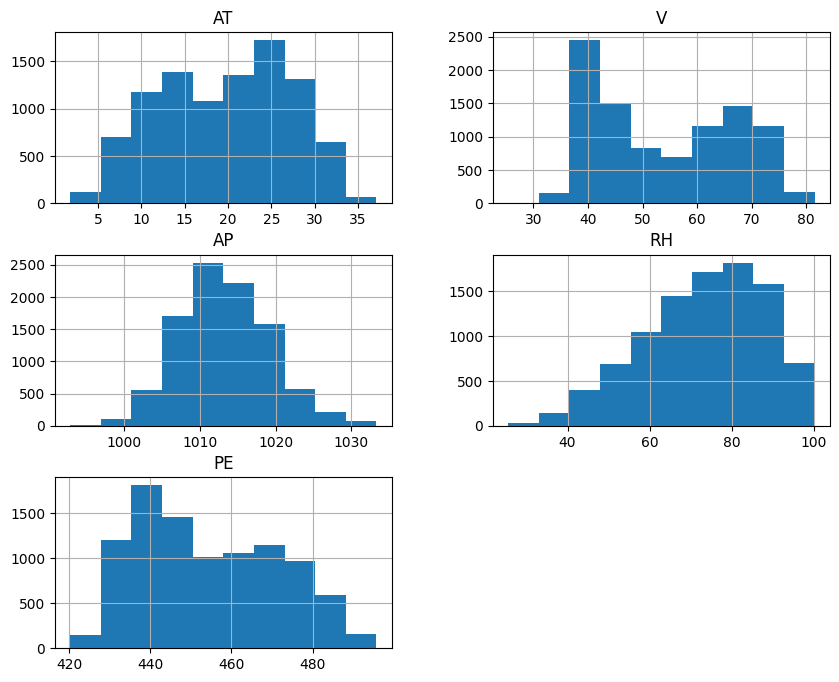

In [ ]:
df.hist(figsize=(10,8))

In [ ]:
df.corr()


,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


<Axes: >

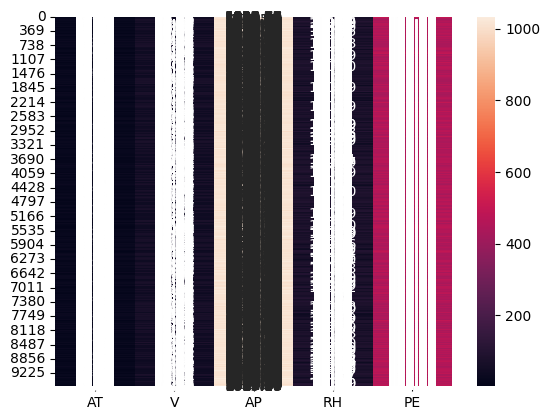

In [ ]:
sns.heatmap(df, annot=True, fmt='.2f')

In [ ]:
y = df['PE']
x = df[['AT', 'V', 'AP', 'RH']]

In [ ]:
print(x.shape)
print(y.shape)

(9568, 4)
(9568,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6697, 4)
(2871, 4)
(6697,)
(2871,)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = model.predict(x_test)

In [ ]:
print (y_pred)

[455.59846369 438.68009712 434.119178   ... 472.39913842 476.10393901
 442.00430919]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(mae, mse, rmse, r2)

3.6499328441754617 21.239856938225508 4.60867192781451 0.9275484963869204


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(LinearRegression(), x_train, y_train, cv=5, scoring='r2')

In [ ]:
print(scores)
print(scores.mean())
print(scores.std())

[0.92790235 0.92534397 0.93595231 0.92220505 0.93316059]
0.9289128526237537
0.005026924091527793


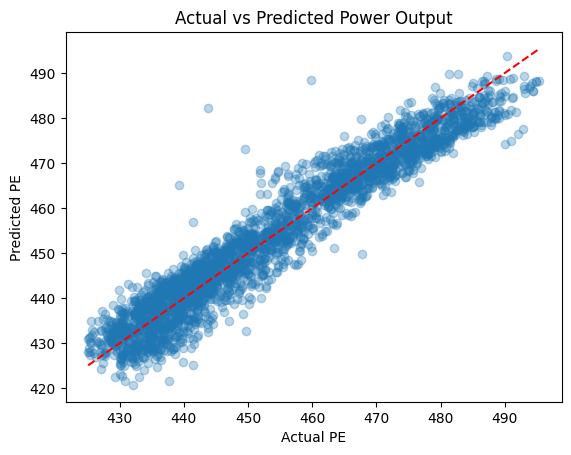

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual PE')
plt.ylabel('Predicted PE')
plt.title('Actual vs Predicted Power Output')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(x_test)

In [ ]:
print (y_pred)

[454.7181 435.8559 435.3458 ... 473.5893 479.0597 443.2869]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(mae, mse, rmse, r2)

2.3921938697318006 11.220838114301591 3.349751948174908 0.9617244788632732


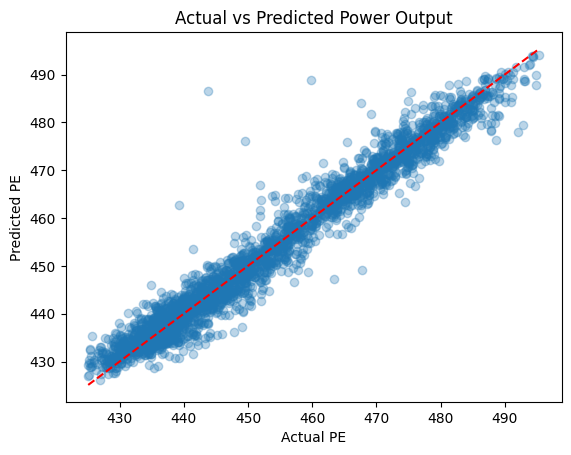

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual PE')
plt.ylabel('Predicted PE')
plt.title('Actual vs Predicted Power Output')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()